<div align="center">
<p align="center" style="width: 100%;">
    <img src="https://raw.githubusercontent.com/vlm-run/.github/refs/heads/main/profile/assets/vlm-black.svg" alt="VLM Run Logo" width="80" style="margin-bottom: -5px; color: #2e3138; vertical-align: middle; padding-right: 5px;"><br>
</p>
<p align="center"><a href="https://vlm.run"><b>Website</b></a> | <a href="https://docs.vlm.run/"><b>API Docs</b></a> | <a href="https://vlm.run/blog"><b>Blog</b></a> | <a href="https://discord.gg/AMApC2UzVY"><b>Discord</b></a>
</p>
</div>

# 🏥 Extracting Handwritten Medical Forms to JSON with VLM Run

In this notebook, we'll extract structured data from a **handwritten physician referral PDF** using VLM Run with **visual grounding** (bounding boxes) so we can see exactly where each field was extracted from on the page.

## 📁 Setup: Upload Your Document and API Key

Before running this notebook, you'll need to setup a few things:

### 1. Upload your handwritten document

Bring a handwritten document you'd like to process. Upload it using the Colab file browser (left sidebar → folder icon → upload) into the working directory (`/content/`).

In the examples below, the file is referenced as `1.pdf`, but you can name yours anything — just update the filename in the code cells to match what you uploaded.

### 2. Add your API key

You'll also need your `VLMRUN_API_KEY` — you can either drop it into a `.env` file in `/content/`, or add it to the **Secrets** tab (🔑 icon on the left sidebar) so it persists across sessions.

## ⚙️ Setup

Install the required packages:

In [1]:
!pip install vlmrun --upgrade --quiet
!pip install python-dotenv --quiet

## 🔑 Load API Key

Load your `VLMRUN_API_KEY`. Note that the way you load the API key may changed based on how you upload it.

In [2]:
import os
from google.colab import userdata

# change loading if needed
VLMRUN_API_KEY = userdata.get("VLMRUN_API_KEY")

assert VLMRUN_API_KEY is not None, "VLMRUN_API_KEY not found. Make sure you upload your VLMRUN_API_KEY"
print("✅ API key loaded")

✅ API key loaded


## 🚀 Initialize the VLM Run Client

In [3]:
from vlmrun.client import VLMRun
from vlmrun.client.types import GenerationConfig, AgentSkill

# Instantiate the client. All subsequent API calls go through this object.
client = VLMRun(api_key=VLMRUN_API_KEY)

## 📄 Run the Physician Referral Extraction Skill

We'll call `client.document.generate` on the document using the `physician-referral-extraction` skill with **grounding** and **confidence** enabled so we get bounding boxes for each extracted field.

In [4]:
# Update this to match the filename you uploaded to /content/
PDF_PATH = "/content/1.pdf"
assert os.path.exists(PDF_PATH), f"Could not find {PDF_PATH}. Upload to /content/ first."

response = client.document.generate(
    file=PDF_PATH,
    config=GenerationConfig(
        skills=[AgentSkill(skill_name="physician-referral-extraction", skill_version="20260408-9c3a43f5")],
        grounding=True,
        confidence=True,
        detail="hi"
    ),
)

print("✅ Extraction complete")

✅ Extraction complete


In [5]:
# Example curl command:
#
# curl -X POST https://api.vlm.run/v1/document/generate \
#   -H 'Authorization: Bearer [insert API key here]' \
#   -H 'Content-Type: application/json' \
#   -d '{
#   "model": "vlm-1",
#   "file_id": "[insert file ID here]",
#   "config": {
#     "skills": [
#       {
#         "skill_name": "physician-referral-extraction",
#         "skill_version": "20260408-9c3a43f5"
#       }
#     ]
#   }
# }'

## 🧾 Inspect the Raw JSON Response

The response contains the structured fields the skill extracted from the document, plus per-field metadata such as bounding boxes and confidence scores.

In [6]:
import json

result = response.model_dump()
print(json.dumps(result, indent=2, default=str))

{
  "id": "71e955fe-ae56-42a5-a8ea-9c79ad1b3572",
  "created_at": "2026-04-10 19:46:40.060878",
  "completed_at": "2026-04-10 19:47:13.013135+00:00",
  "response": {
    "diagnosis": "back pain",
    "patient_condition_details": "sustained back pain that doesn't go away after initial treatment",
    "patient_details": {
      "date_of_birth": "2001-09-15",
      "email": "kevinchen@gmail.com",
      "first_name": "Kevin",
      "last_name": "chen",
      "preferred_phone_number": "6153012311",
      "date_of_birth_metadata": {
        "confidence": "hi",
        "bboxes": [
          {
            "content": "9/15/2001",
            "bbox": {
              "xywh": [
                0.6163,
                0.1968,
                0.1675,
                0.0264
              ]
            },
            "page": 0,
            "confidence": 0.82
          }
        ]
      },
      "email_metadata": {
        "confidence": "med",
        "bboxes": [
          {
            "content": "ker

## 🖼️ Visualize the Bounding Boxes

Now let's render the bounding boxes from the grounding metadata onto the PDF page so we can see exactly where each field was extracted from. We'll convert the PDF to an image first, then draw the bboxes on top.

A few things going on in the cell below:

1. **Rasterize the PDF** with `pdf_images` from the VLM Run SDK so each page becomes a PIL image we can draw on.
2. **Walk the response recursively** with `collect_bboxes` to find every `_metadata.bboxes[...]` entry and pair it with the structured field value it describes.
3. **Align OCR chunks to the final value.** When a single field (e.g. a long address) is grounded by *multiple* bboxes, the per-bbox OCR text doesn't always match the cleaned/normalized final value character-for-character. `align_initial_to_final` uses fuzzy string matching to slice the final value into pieces that line up with each bbox, so each region gets a sensible label.
4. **Draw the boxes** onto each page and display them inline.

You can switch between two label modes with the `USE_TEXT_SOURCE` flag:
- `"initial"` — show the raw per-region OCR text and its numeric confidence score
- `"final"` — show the structured/normalized value (recommended for a clean visualization)

In [7]:
# pypdfium2 is used under the hood by vlmrun.common.pdf to rasterize PDF pages
!pip install pypdfium2 --quiet

In [8]:
# Helper to load a TrueType font for drawing labels on top of bboxes.
# Tries a few common Linux font paths (Colab usually has DejaVu installed),
# then falls back to Pillow's default bitmap font if nothing is available.
def get_font(size):
    font_paths = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
    ]
    for p in font_paths:
        try:
            return ImageFont.truetype(p, size)
        except Exception:
            continue
    # Last resort: load_default with size (Pillow 10+)
    try:
        return ImageFont.load_default(size=size)
    except TypeError:
        print("⚠️  No TrueType font found and Pillow is too old for sized default. Run: !apt-get install -y fonts-dejavu-core")
        return ImageFont.load_default()

PDF has 1 page(s)
Found 19 grounded fields (text source: final)
Page 1 — 19 boxes


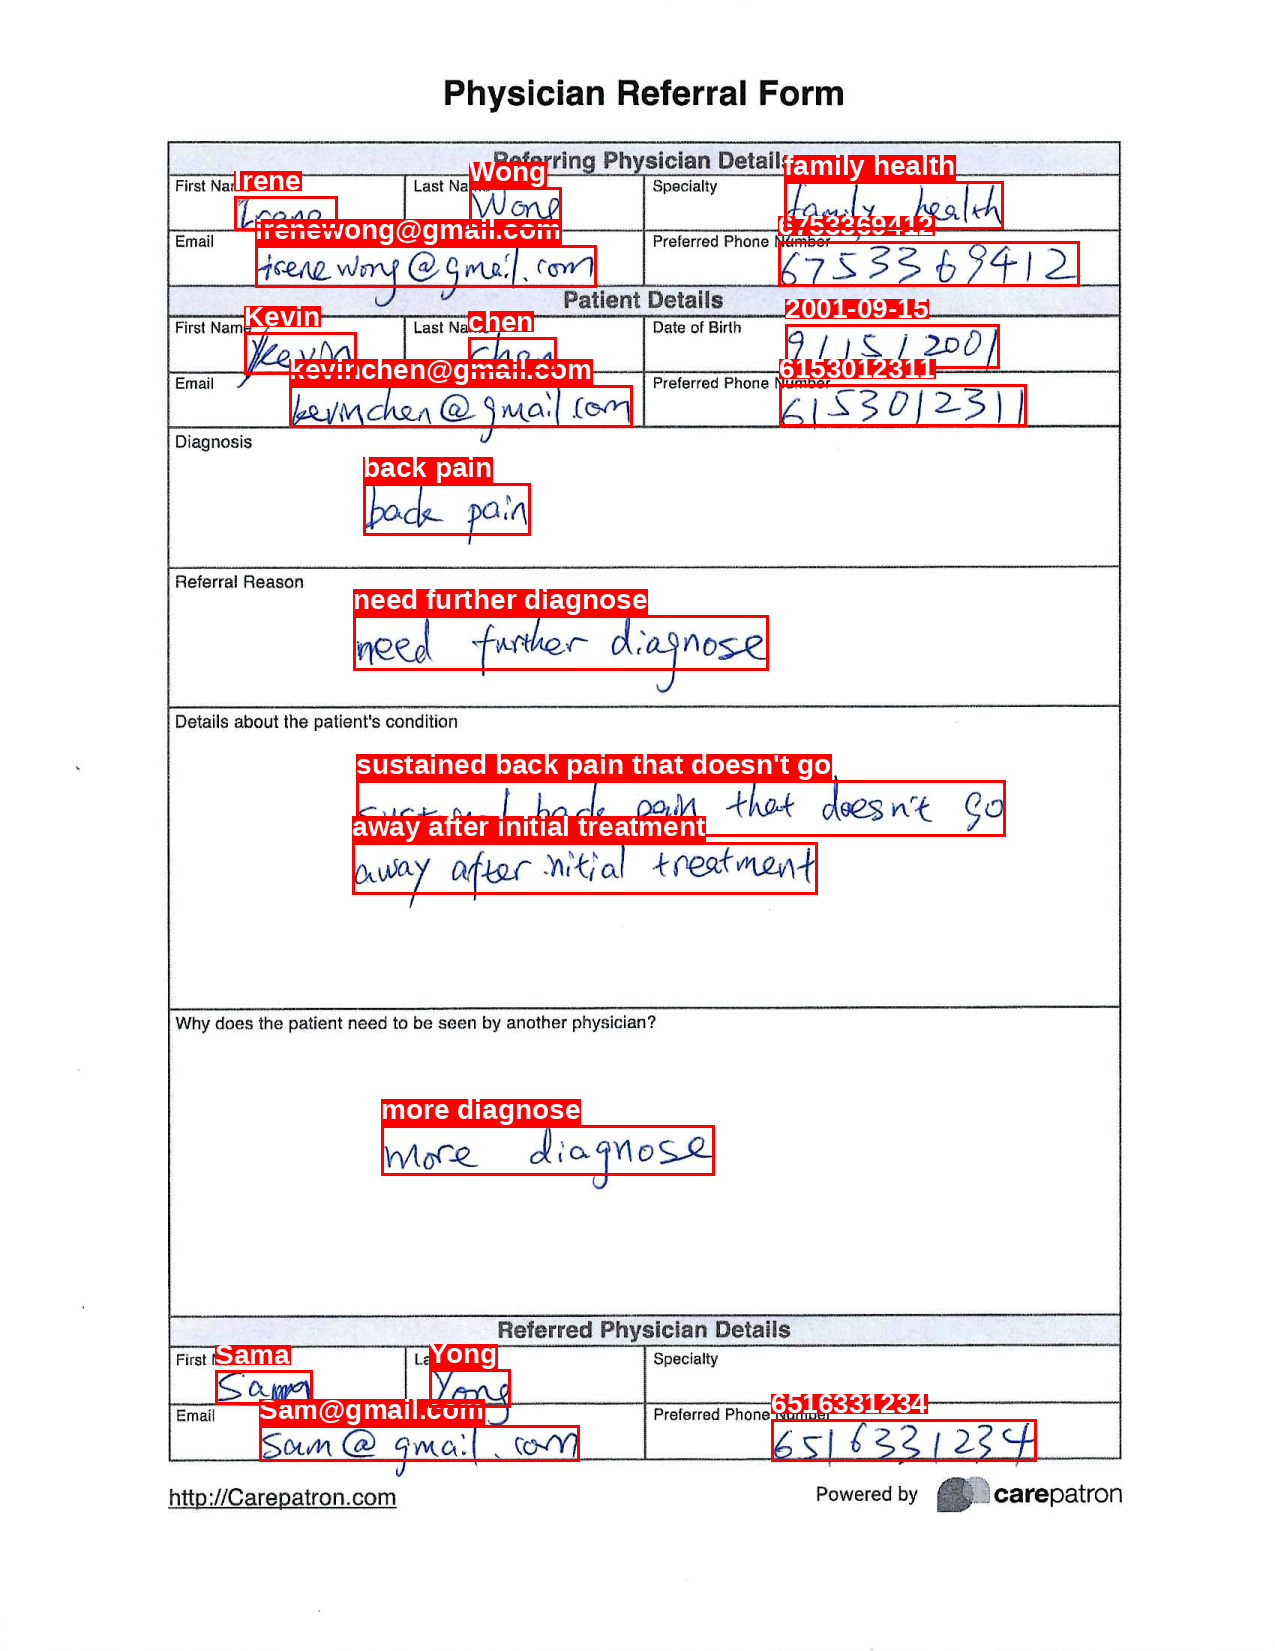

In [9]:
from pathlib import Path
from PIL import ImageDraw, ImageFont
from IPython.display import display
from difflib import SequenceMatcher
from vlmrun.common.pdf import pdf_images

# Convert PDF pages to PIL images using the VLM Run SDK helper
pdf_pages = list(pdf_images(Path(PDF_PATH), dpi=150))
print(f"PDF has {len(pdf_pages)} page(s)")

# ──────────────────────────────────────────────────────────────
# Flag: which text to display on bboxes in the visualization
#   "initial" → initial value found with bbox detection
#   "final"   → final improved value
USE_TEXT_SOURCE = "final"
# ──────────────────────────────────────────────────────────────

response_data = result.get("response", result)


def get_by_path(obj, path):
    """Walk a dotted/indexed path like 'patient.email' or 'items[0].name' into obj."""
    import re
    tokens = re.findall(r"[^.\[\]]+|\[\d+\]", path)
    cur = obj
    for tok in tokens:
        if tok.startswith("["):
            cur = cur[int(tok[1:-1])]
        else:
            if not isinstance(cur, dict) or tok not in cur:
                return None
            cur = cur[tok]
    return cur


def resolve_field_value(full_path, root):
    """Given a bbox path like 'patient.email_metadata.bboxes[0]', return the value at 'patient.email'."""
    base = full_path.rsplit(".bboxes[", 1)[0]
    field_path = base.replace("_metadata", "")
    return get_by_path(root, field_path)


def align_initial_to_final(final_text, initial_chunks):
    """Split final_text into slices corresponding to each initial OCR chunk, using fuzzy alignment."""
    if not final_text or not initial_chunks:
        return [final_text or ""] * len(initial_chunks)

    final = str(final_text)
    final_lower = final.lower()

    anchors = []
    for chunk in initial_chunks:
        chunk_str = str(chunk or "").lower().strip()
        if not chunk_str:
            anchors.append(None)
            continue
        matcher = SequenceMatcher(None, final_lower, chunk_str, autojunk=False)
        match = matcher.find_longest_match(0, len(final_lower), 0, len(chunk_str))
        if match.size == 0:
            anchors.append(None)
        else:
            center = match.a + match.size // 2
            half = max(len(chunk_str) // 2, match.size // 2)
            anchors.append((max(0, center - half), min(len(final), center + half)))

    if any(a is None for a in anchors):
        n = len(initial_chunks)
        step = len(final) / n
        return [final[int(i * step):int((i + 1) * step)].strip() for i in range(n)]

    indexed = sorted(enumerate(anchors), key=lambda x: x[1][0])
    order = [i for i, _ in indexed]
    sorted_anchors = [a for _, a in indexed]

    boundaries = [0]
    for i in range(len(sorted_anchors) - 1):
        mid = (sorted_anchors[i][1] + sorted_anchors[i + 1][0]) // 2
        boundaries.append(mid)
    boundaries.append(len(final))

    def snap_to_space(idx):
        if idx <= 0 or idx >= len(final):
            return idx
        left = final.rfind(" ", 0, idx)
        right = final.find(" ", idx)
        if left == -1 and right == -1:
            return idx
        if left == -1:
            return right
        if right == -1:
            return left
        return left if (idx - left) <= (right - idx) else right

    boundaries = [snap_to_space(b) for b in boundaries]
    slices_in_order = [final[boundaries[i]:boundaries[i + 1]].strip()
                       for i in range(len(boundaries) - 1)]

    result_slices = [""] * len(initial_chunks)
    for sorted_i, original_i in enumerate(order):
        result_slices[original_i] = slices_in_order[sorted_i]
    return result_slices


def collect_bboxes(obj, path=""):
    """Recursively walk the response dict and collect
    (field_name, page_index, xywh, initial_text, initial_text_confidence,
     final_text, final_text_confidence) tuples.
    - initial_text / initial_text_confidence: per-bbox OCR content + scalar score
    - final_text / final_text_confidence: improved value + string-level confidence ("hi"/"med"/"lo")
    """
    found = []
    if isinstance(obj, dict):
        bbox = obj.get("bbox")
        if isinstance(bbox, dict) and bbox.get("xywh"):
            return found
        for k, v in obj.items():
            if k == "bboxes" and isinstance(v, list) and v:
                # The string-level confidence lives on the parent _metadata dict (sibling of "bboxes")
                final_text_confidence = obj.get("confidence", None)

                entries = []
                for i, item in enumerate(v):
                    if not isinstance(item, dict):
                        continue
                    inner_bbox = item.get("bbox")
                    if not (isinstance(inner_bbox, dict) and inner_bbox.get("xywh")):
                        continue
                    entries.append({
                        "path": f"{path}.{k}[{i}]" if path else f"{k}[{i}]",
                        "xywh": inner_bbox["xywh"],
                        "page": item.get("page", inner_bbox.get("page", 0)),
                        "initial_text": item.get("content", ""),
                        "confidence": item.get("confidence", None),
                    })
                if entries:
                    final_value = resolve_field_value(entries[0]["path"], response_data)
                    if final_value is None:
                        final_texts = [e["initial_text"] for e in entries]
                    elif len(entries) == 1:
                        final_texts = [final_value]
                    else:
                        final_texts = align_initial_to_final(
                            final_value, [e["initial_text"] for e in entries]
                        )
                    for e, final_text in zip(entries, final_texts):
                        found.append((
                            e["path"],
                            e["page"],
                            e["xywh"],
                            e["initial_text"],
                            e["confidence"],
                            final_text,
                            final_text_confidence,
                        ))
            else:
                found.extend(collect_bboxes(v, f"{path}.{k}" if path else k))
    elif isinstance(obj, list):
        for i, v in enumerate(obj):
            found.extend(collect_bboxes(v, f"{path}[{i}]"))
    return found


bboxes = collect_bboxes(response_data)
print(f"Found {len(bboxes)} grounded fields (text source: {USE_TEXT_SOURCE})")


def draw_bboxes_on_page(page_img, page_bboxes):
    img = page_img.copy().convert("RGB")
    draw = ImageDraw.Draw(img)
    W, H = img.size
    FONT_SIZE = 28
    try:
        font = get_font(FONT_SIZE)
    except Exception:
        font = ImageFont.load_default()

    for field, _page, xywh, initial_text, confidence, final_text, _final_conf in page_bboxes:
        x, y, w, h = xywh
        x0, y0 = int(x * W), int(y * H)
        x1, y1 = int((x + w) * W), int((y + h) * H)
        draw.rectangle([x0, y0, x1, y1], outline="red", width=3)
        field_name = field.split(".")[-1].replace("_metadata", "")

        if USE_TEXT_SOURCE == "initial":
            text = str(initial_text) if initial_text else field_name
            label = f"{text} [{confidence:.2f}]" if confidence is not None else text
        else:  # "final"
            text = str(final_text) if final_text else field_name
            label = text

        label_y = max(0, y0 - FONT_SIZE - 4)
        text_bbox = draw.textbbox((x0, label_y), label, font=font)
        draw.rectangle(text_bbox, fill="red")
        draw.text((x0, label_y), label, fill="white", font=font)
    return img


for page_obj in pdf_pages:
    page_idx = page_obj.page_number
    page_img = page_obj.image
    page_bboxes = [b for b in bboxes if b[1] == page_idx] or (bboxes if len(pdf_pages) == 1 else [])
    annotated = draw_bboxes_on_page(page_img, page_bboxes)
    print(f"Page {page_idx + 1} — {len(page_bboxes)} boxes")
    display(annotated)

## 📋 Field Summary Table

A table of every grounded field, the value extracted from the page, and the bounding box content.

Columns:
- **field** — dotted path to the field in the response (e.g. `patient.date_of_birth`)
- **page** — 1-indexed page number
- **final_text** — the final improved value
- **final_text_confidence** — string-level confidence (`hi` / `med` / `lo`)
- **initial_text** — initial text extraction for this specific bbox
- **initial_text_confidence** — numeric confidence for the initial OCR
- **xywh** — normalized bounding box `[x, y, width, height]` in `[0, 1]` coordinates

In [10]:
import pandas as pd

rows = [
    {
        "field": field.replace("_metadata", ""),
        "page": page_idx + 1,
        "final_text": final_text,
        "final_text_confidence": final_text_confidence,
        "initial_text": initial_text,
        "initial_text_confidence": confidence,
        "xywh": [round(v, 3) for v in xywh],
    }
    for field, page_idx, xywh, initial_text, confidence, final_text, final_text_confidence in bboxes
]
df = pd.DataFrame(rows)
df

,field,page,final_text,final_text_confidence,initial_text,initial_text_confidence,xywh
0,patient_details.date_of_birth.bboxes[0],1,2001-09-15,hi,9/15/2001,0.82,"[0.616, 0.197, 0.168, 0.026]"
1,patient_details.email.bboxes[0],1,kevinchen@gmail.com,med,kerimchen@gmail.com,0.59,"[0.227, 0.233, 0.269, 0.025]"
2,patient_details.first_name.bboxes[0],1,Kevin,hi,Kevin,0.66,"[0.192, 0.201, 0.088, 0.025]"
3,patient_details.last_name.bboxes[0],1,chen,hi,chen,0.99,"[0.367, 0.205, 0.069, 0.021]"
4,patient_details.preferred_phone_number.bboxes[0],1,6153012311,hi,6153012311,0.99,"[0.611, 0.233, 0.194, 0.025]"
5,referred_physician_details.email.bboxes[0],1,Sam@gmail.com,hi,Sam@gmail.com,0.92,"[0.203, 0.863, 0.251, 0.022]"
6,referred_physician_details.first_name.bboxes[0],1,Sama,hi,Sama,0.70,"[0.169, 0.83, 0.076, 0.021]"
7,referred_physician_details.last_name.bboxes[0],1,Yong,hi,Yong,0.89,"[0.337, 0.83, 0.064, 0.023]"
8,referred_physician_details.preferred_phone_num...,1,6516331234,hi,6516331234,0.99,"[0.605, 0.86, 0.208, 0.025]"
9,referring_physician_details.email.bboxes[0],1,irenewong@gmail.com,med,treneworry@gmail.com,0.61,"[0.2, 0.148, 0.267, 0.026]"
